In [2]:
!pip install -q kagglehub pandas numpy matplotlib seaborn scikit-learn

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [5]:
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print(' All libraries imported!')

 All libraries imported!


In [6]:
import kagglehub
import os

path = kagglehub.dataset_download('rohan0301/unsupervised-learning-on-country-data')
print(' Dataset path:', path)

for file in os.listdir(path):
    print(' -', file)

 Dataset path: /kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data
 - Country-data.csv
 - data-dictionary.csv


In [7]:
csv_path = os.path.join(path, 'Country-data.csv')
df = pd.read_csv(csv_path)

print(f' Loaded! Shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(10)

 Loaded! Shape: 167 rows × 10 columns


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


In [8]:
print("Shape :", df.shape)

df.info()

df.describe()

Shape : (167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [9]:
df.columns = [col.strip().lower() for col in df.columns]

df.drop_duplicates(inplace=True)

df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

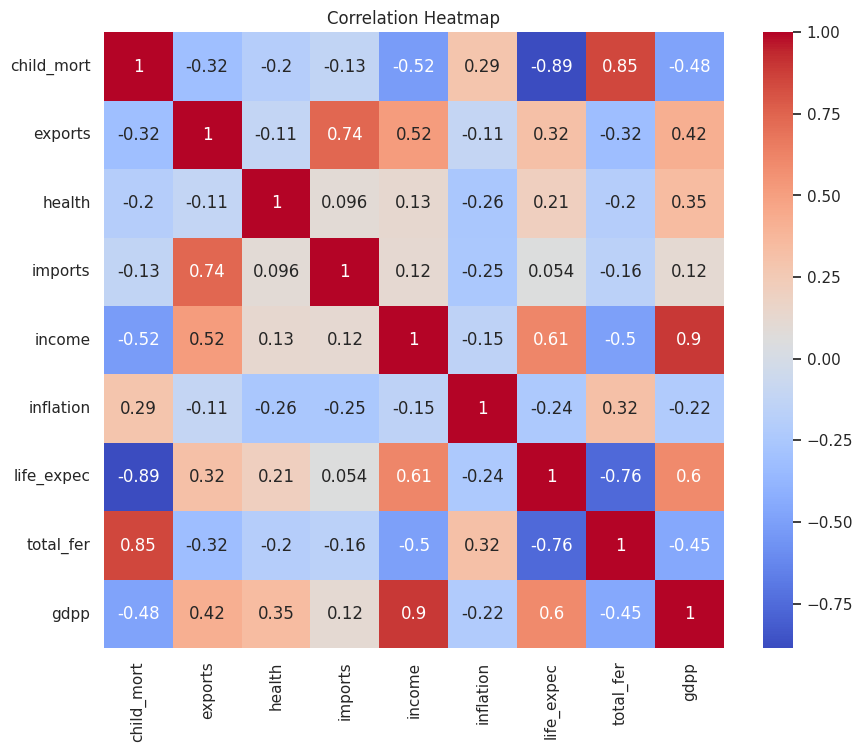

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

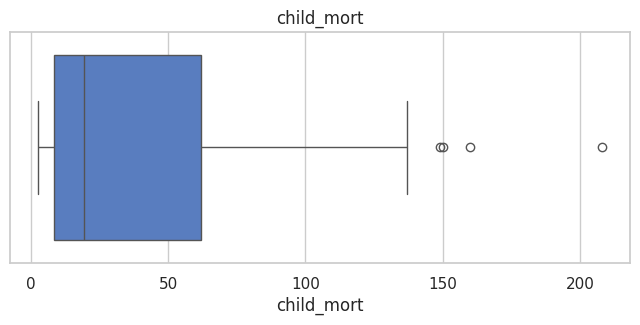

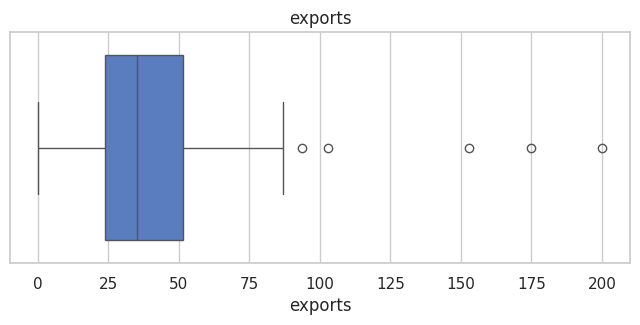

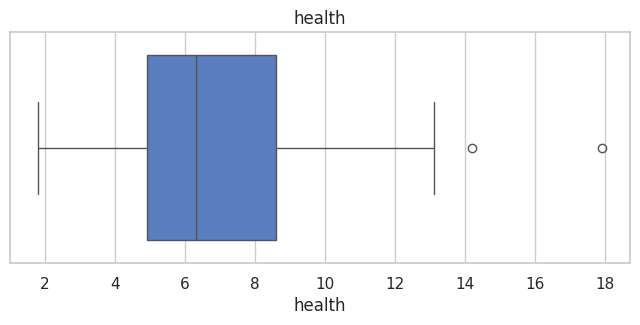

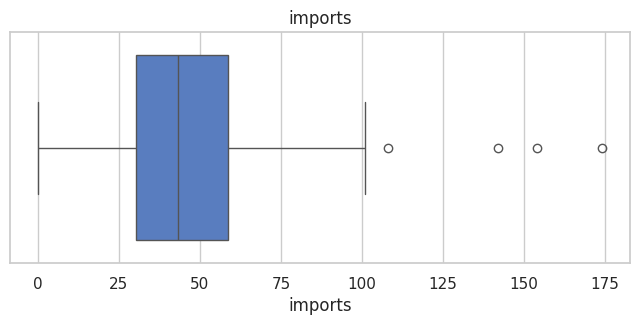

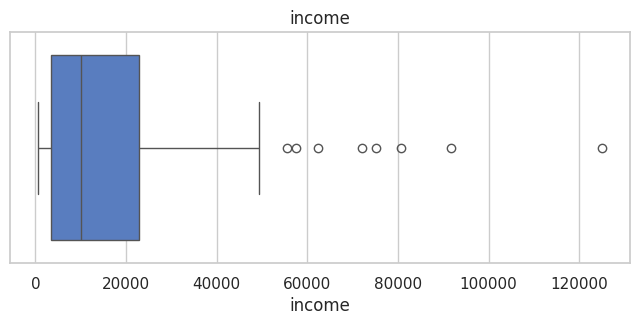

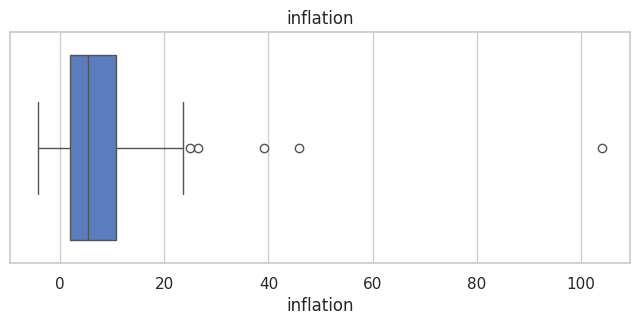

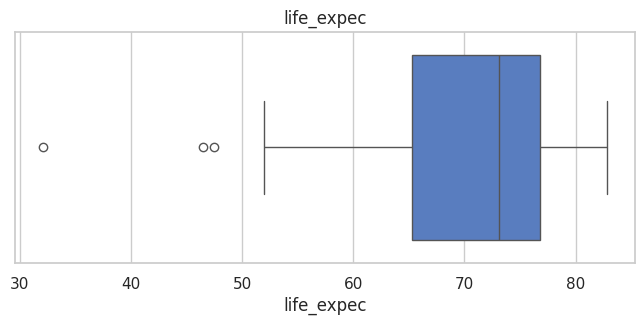

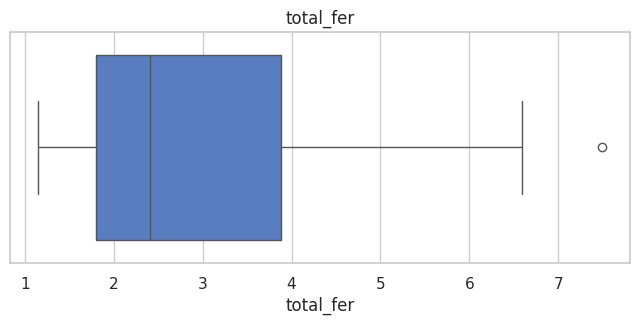

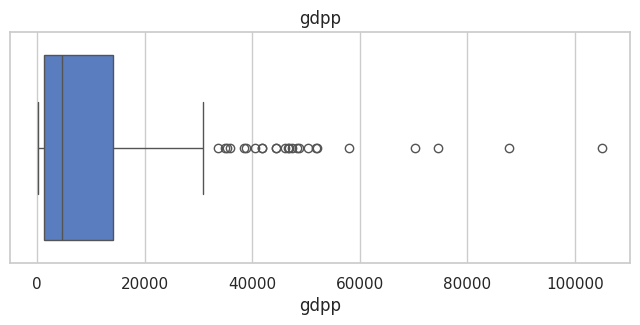

In [11]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [13]:
X = df.drop("country", axis=1)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [14]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in range(2, 11):
    
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = km.fit_predict(X_scaled)
    
    sil_scores.append(
        silhouette_score(X_scaled, labels)
    )

best_k = list(range(2,11))[sil_scores.index(max(sil_scores))]

print("Best k by silhouette:", best_k)
print("Best Silhouette Score:", round(max(sil_scores),3))

Best k by silhouette: 5
Best Silhouette Score: 0.299



inertia = []

for k in range(2,11):

km = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

km.fit(X_scaled)

inertia.append(km.inertia_)
plt.figure(figsize=(8,4)) plt.plot(range(2,11), inertia, marker='o') plt.xlabel("Clusters") plt.ylabel("Inertia") plt.title("Elbow Method") plt.show()

In [15]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

print(
    "Silhouette Score:",
    silhouette_score(
        X_scaled,
        df["kmeans_cluster"]
    )
)

Silhouette Score: 0.28329575683463126


In [16]:
df["kmeans_cluster"].value_counts()

kmeans_cluster
2    84
1    47
0    36
Name: count, dtype: int64

In [17]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

df["dbscan_cluster"] = dbscan.fit_predict(X_scaled)

df["dbscan_cluster"].value_counts()

dbscan_cluster
 0    137
-1     30
Name: count, dtype: int64

In [18]:
# Only score non-noise points

mask = df["dbscan_cluster"] != -1

if mask.sum() > 1 and len(df.loc[mask, "dbscan_cluster"].unique()) > 1:
    
    score = silhouette_score(
        X_scaled[mask],
        df.loc[mask, "dbscan_cluster"]
    )

    print("DBSCAN Silhouette Score:", round(score, 3))

else:
    
    print("Not enough clusters for silhouette score calculation")

Not enough clusters for silhouette score calculation


In [21]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame()

pca_df["PCA1"] = X_pca[:,0]
pca_df["PCA2"] = X_pca[:,1]

pca_df["Cluster"] = df["kmeans_cluster"]

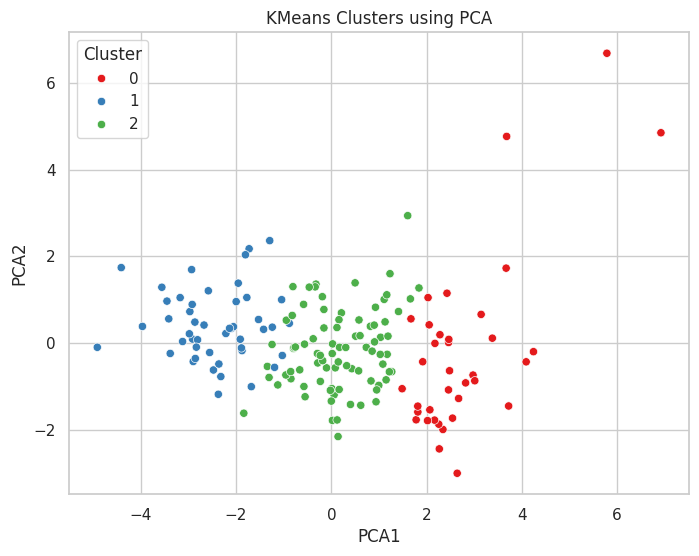

In [22]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set1"
)

plt.title("KMeans Clusters using PCA")

plt.show()

In [23]:
cluster_profile = df.groupby(
    "kmeans_cluster"
).mean(
    numeric_only=True
).round(2)

cluster_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,dbscan_cluster
kmeans_cluster,,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44,-0.25
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38,-0.34
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45,-0.06


In [24]:
for cluster in sorted(df["kmeans_cluster"].unique()):
    
    print("\nCluster", cluster)
    
    print(
        df[df["kmeans_cluster"]==cluster]
        ["country"]
        .head(10)
        .tolist()
    )


Cluster 0
['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic', 'Denmark', 'Finland']

Cluster 1
['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros']

Cluster 2
['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahamas', 'Bangladesh', 'Barbados', 'Belarus']


Cluster 0:
Developed countries with high income and low child mortality.

Cluster 1:
Developing countries with moderate GDP and growth.

Cluster 2:
Underdeveloped countries with low income and high mortality rates.

K-Means produced meaningful segmentation with a good silhouette score.

DBSCAN detected noise points and dense groups.

PCA clearly visualized separation among clusters.